In [1]:
import numpy as np
import matplotlib.pyplot as plt
import torch
from IPython.display import display
from collections import OrderedDict

In [2]:
seed = 0
np.random.seed(seed)
torch.manual_seed(seed)

In [3]:
from pathlib import Path
import sys

repo_root = Path().resolve().parent  # notebook is in repo_root/examples
sys.path.insert(0, str(repo_root))
from stbo.optimization import BOController

In [4]:
n_init = 4
n_global = 0
n_local = 16
n_finetune = 2

local_init = n_global == 0

In [5]:
n_control = 4
n_bpm = 3
n_bcm = 1
n_fc = 1
n_monitor = n_bpm*3 + n_bcm + n_fc

control_CSETs= [f'X{i+1}:I_CSET' for i in range(n_control)]
control_RDs  = [f'X{i+1}:I_RD' for i in range(n_control)]
control_tols = [0.1]*len(control_CSETs)
control_min  = [ -1]*len(control_CSETs)
control_max  = [  1]*len(control_CSETs)
bpm_xRDs     = [f'BPM{i+1}:XPOS_RD' for i in range(n_bpm)]
bpm_yRDs     = [f'BPM{i+1}:YPOS_RD' for i in range(n_bpm)]
bpm_phRDs    = [f'BPM{i+1}:PHASE_RD' for i in range(n_bpm)]
current_RDs  = [f'BCM:PKAVG_RD', f'FC:PKAVG_RD']
monitor_PVs  = bpm_xRDs + bpm_yRDs + bpm_phRDs + current_RDs
oracle_key_names = {
    'x':control_RDs,
    'y':'composite_obj'
}

control_bounds = torch.tensor([control_min, control_max], dtype=torch.float64)

In [6]:
FC814 = 50

objective_goal = OrderedDict([
    ('BPM1:XPOS_RD',  -0.345812289535008),
    ('BPM1:YPOS_RD',   0.2755291980547795),
    ('BPM1:PHASE_RD', 80.01379620843083),
    ('BPM2:XPOS_RD',   0.11800521457630664),
    ('BPM2:YPOS_RD',   0.4313544346071099),
    ('BPM2:PHASE_RD', -23.42850231099402),
    ('BPM3:XPOS_RD',   0.04434067124873937),
    ('BPM3:YPOS_RD',  -0.15548171891011758),
    ('BPM3:PHASE_RD', -14.992799801690156),
    ('BCM:PKAVG_RD',  {'more than': FC814}),
    ('FC:PKAVG_RD',   {'more than': 0.8 * FC814}),
])

objective_tolerance = OrderedDict([
    ('BPM1:XPOS_RD',  1),
    ('BPM1:YPOS_RD',  1),
    ('BPM1:PHASE_RD', 1),
    ('BPM2:XPOS_RD',  1),
    ('BPM2:YPOS_RD',  1),
    ('BPM2:PHASE_RD', 1),
    ('BPM3:XPOS_RD',  1),
    ('BPM3:YPOS_RD',  1),
    ('BPM3:PHASE_RD', 1),
    ('BCM:PKAVG_RD',  0.01 * FC814),
    ('FC:PKAVG_RD',   0.05 * 0.8 * FC814),
])

objective_weight = OrderedDict([
    ('BPM1:XPOS_RD',  0.8),
    ('BPM1:YPOS_RD',  0.8),
    ('BPM1:PHASE_RD', 1),
    ('BPM2:XPOS_RD',  0.3),
    ('BPM2:YPOS_RD',  0.3),
    ('BPM2:PHASE_RD', 0.5),
    ('BPM3:XPOS_RD',  0.1),
    ('BPM3:YPOS_RD',  0.1),
    ('BPM3:PHASE_RD', 0.3),
    ('BCM:PKAVG_RD',  2),
    ('FC:PKAVG_RD',   2),
])


# setup simEPICS

In [7]:
repo_io = Path().resolve().parent.parent / "simEPICS"
sys.path.insert(0, str(repo_io))
from sim_ioc_lib import create_interactive_ioc, run_ioc_background

input_pv_info = {cset:{'rd':cset.replace('CSET','RD')} for cset in control_CSETs}
output_pv_info = {}
for pv in objective_goal.keys():
    if isinstance(objective_goal[pv],dict):
        goal = list(objective_goal[pv].values())[0]
    else:
        goal = objective_goal[pv]
    output_pv_info[pv] = {'min':goal-3*objective_tolerance[pv], 
                          'max':goal+3*objective_tolerance[pv]}
    
my_ioc = create_interactive_ioc(input_pv_info, output_pv_info, seed=0)
ioc_loop, ioc_thread = run_ioc_background(my_ioc)

print("IOC running. PVs available:")
for pv in my_ioc.pvdb:
    print(f" - {pv}")

IOC running. PVs available:
 - X1:I_CSET
 - X1:I_RD
 - X2:I_CSET
 - X2:I_RD
 - X3:I_CSET
 - X3:I_RD
 - X4:I_CSET
 - X4:I_RD
 - BPM1:XPOS_RD
 - BPM1:YPOS_RD
 - BPM1:PHASE_RD
 - BPM2:XPOS_RD
 - BPM2:YPOS_RD
 - BPM2:PHASE_RD
 - BPM3:XPOS_RD
 - BPM3:YPOS_RD
 - BPM3:PHASE_RD
 - BCM:PKAVG_RD
 - FC:PKAVG_RD


High load. Batched 4 commands (160B) with 0.0470s latency.
High load. Batched 4 commands (160B) with 0.0310s latency.
High load. Batched 3 commands (120B) with 0.0310s latency.
High load. Batched 2 commands (80B) with 0.0310s latency.
High load. Batched 6 commands (240B) with 0.0320s latency.
High load. Batched 12 commands (480B) with 0.0320s latency.
High load. Batched 4 commands (160B) with 0.0470s latency.
High load. Batched 17 commands (680B) with 0.0310s latency.
High load. Batched 2 commands (80B) with 0.0310s latency.
High load. Batched 5 commands (200B) with 0.0320s latency.
High load. Batched 14 commands (560B) with 0.0320s latency.
High load. Batched 7 commands (280B) with 0.0310s latency.
High load. Batched 4 commands (160B) with 0.0310s latency.


### open CSstudio plot

In [8]:
from generate_phoebus_plt import generate_phoebus_plt

monitor_groups = [bpm_xRDs,bpm_yRDs,current_RDs,*[[pv] for pv in bpm_phRDs]]
control_CSETs_groups = [control_CSETs]

# Generate and Open
generate_phoebus_plt(
    output_filename="test.plt",
    monitor_groups=monitor_groups,
    control_CSETs_groups=control_CSETs_groups,
    auto_open=True,
)

File generated: C:\Users\HWANG\My Drive\GitHub\stBO\examples\test.plt


# Construct machineIO

In [9]:
repo_io = Path().resolve().parent.parent / "machineIO"
sys.path.insert(0, str(repo_io))
from machineIO import construct_machineIO, Evaluator, OracleEvaluator
from machineIO.objFunc import SingleTaskObjectiveFunction
io = construct_machineIO()

Failed to import 'phantasy'


# test evaluator

In [10]:
ev =  Evaluator(
    io,
    control_CSETs= control_CSETs,
    control_RDs  = control_RDs,
    control_tols = control_tols,
    monitor_PVs  = monitor_PVs,
)

In [11]:
ev.read().head()

,X1:I_CSET,X2:I_CSET,X3:I_CSET,X4:I_CSET,X1:I_RD,X2:I_RD,X3:I_RD,X4:I_RD,BPM1:XPOS_RD,BPM2:XPOS_RD,BPM3:XPOS_RD,BPM1:YPOS_RD,BPM2:YPOS_RD,BPM3:YPOS_RD,BPM1:PHASE_RD,BPM2:PHASE_RD,BPM3:PHASE_RD,BCM:PKAVG_RD,FC:PKAVG_RD
2026-02-03 13:14:22.463961,0.0,0.0,0.0,0.0,-0.000242,-0.000075,-0.001847,0.000022,-0.567913,-1.152276,0.921802,2.823309,-1.886939,1.475020,82.204482,-20.423922,-13.684813,49.856578,45.987401
2026-02-03 13:14:22.739639,0.0,0.0,0.0,0.0,0.001088,-0.000807,0.000283,-0.000275,-0.561399,-1.172227,0.939379,2.825346,-1.881312,1.471713,82.198882,-20.434203,-13.684104,49.851088,45.982642
2026-02-03 13:14:22.975902,0.0,0.0,0.0,0.0,-0.000536,0.000044,0.001268,0.000729,-0.565150,-1.166922,0.936927,2.829767,-1.874712,1.473615,82.208658,-20.431216,-13.669044,49.857879,45.979585
2026-02-03 13:14:23.195230,0.0,0.0,0.0,0.0,0.000372,-0.002195,-0.000790,-0.000192,-0.569194,-1.166114,0.930650,2.826403,-1.877014,1.480158,82.200186,-20.437983,-13.684032,49.851012,45.992369
2026-02-03 13:14:23.415784,0.0,0.0,0.0,0.0,0.000110,-0.001890,0.001160,-0.001183,-0.567025,-1.178347,0.930362,2.821535,-1.872589,1.470323,82.207783,-20.428304,-13.679598,49.859121,45.978435


# define obj_func

In [12]:
obj_func = SingleTaskObjectiveFunction(
    objective_PVs = list(objective_goal.keys()), 
    composite_objective_name = 'composite_obj',
    objective_goal = objective_goal,
    objective_weight = objective_weight,
    objective_tolerance = objective_tolerance,
    p_order = 2,
    apply_bilog = True
)

# define orcle

In [13]:
oracle =  OracleEvaluator(
    io,
    control_CSETs= control_CSETs,
    control_RDs  = control_RDs,
    control_tols = control_tols,
    oracle_key_names = oracle_key_names,
    monitor_PVs  = monitor_PVs,
    df_manipulators = [obj_func.calculate_objectives_from_df],
)

In [14]:
bo = BOController(oracle, 
                  local_init = local_init,
                  bounds = control_bounds)

In [15]:
bo.initialize(budget=n_init, ramping_rate=[10]*len(control_CSETs), seed=0)

In [16]:
for _ in range(n_global):
    bo.step(mode="global", acq_type="qEI", fresh_train=True, plot_acq=True)
    plt.show()

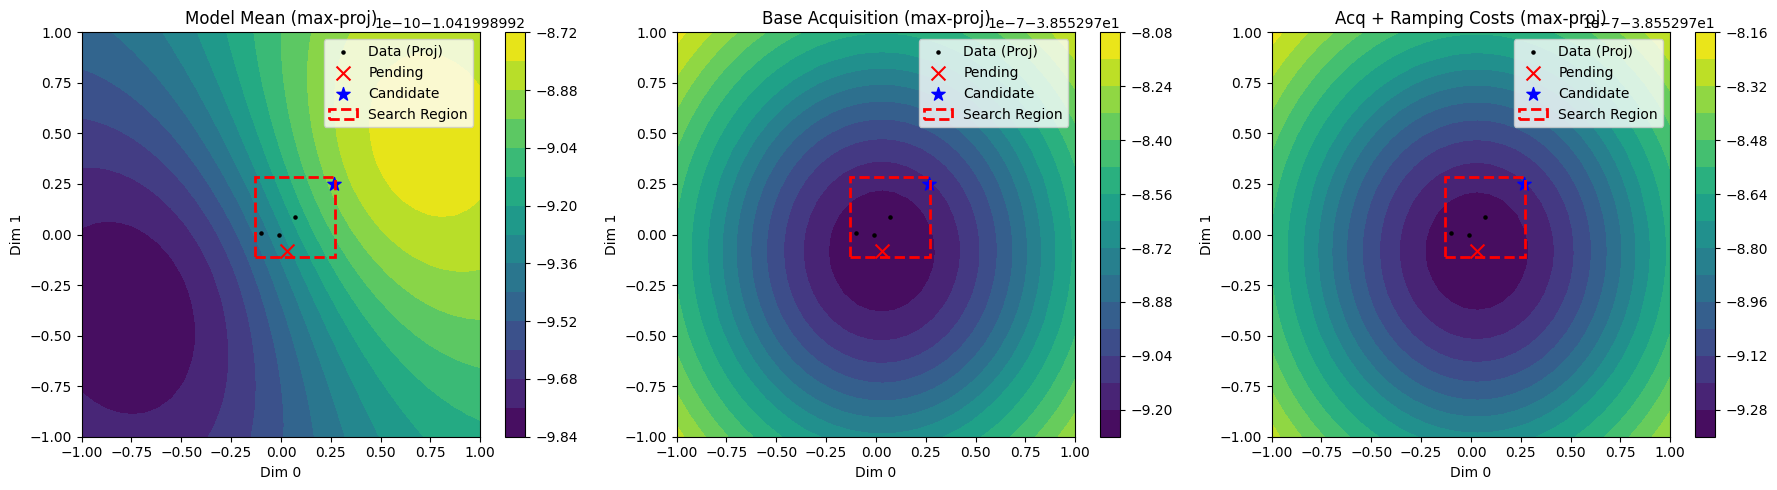

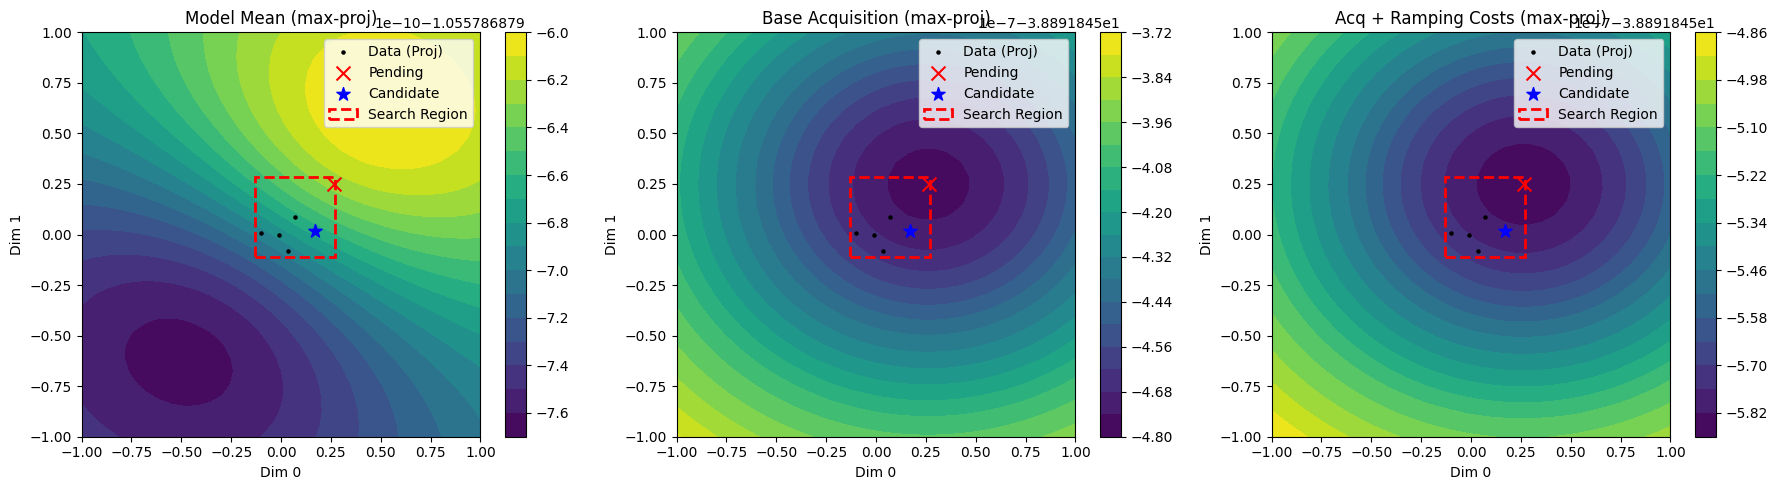

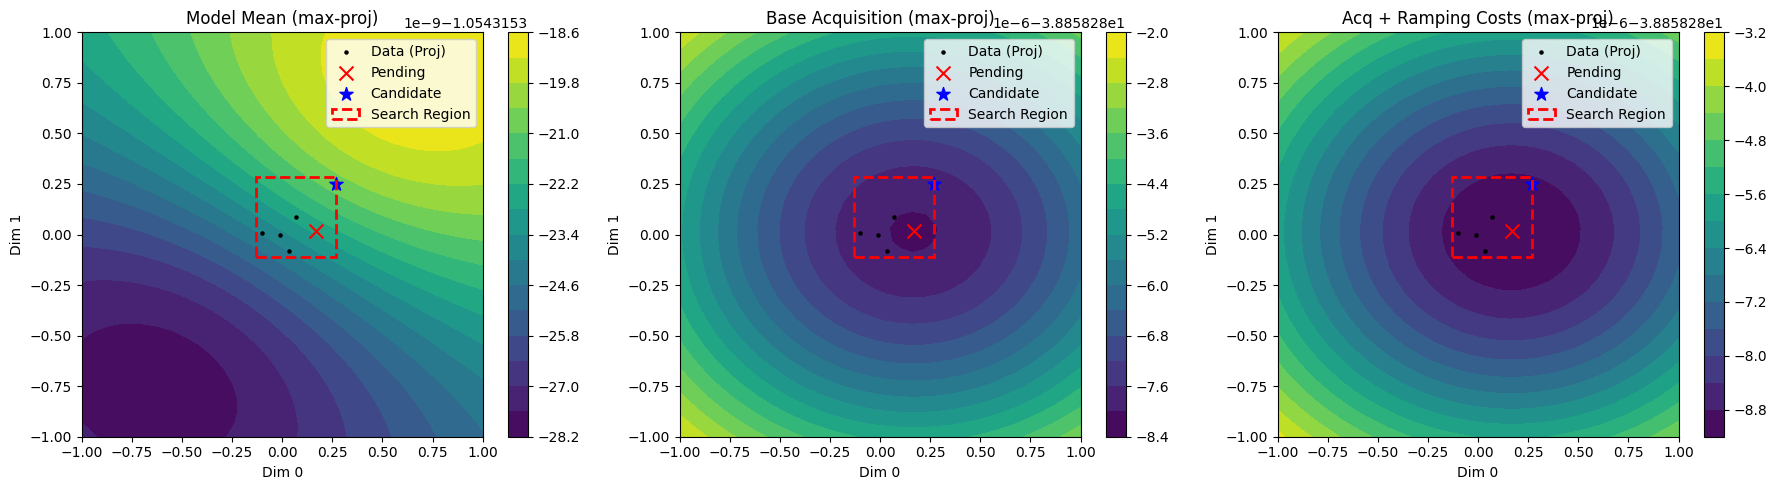

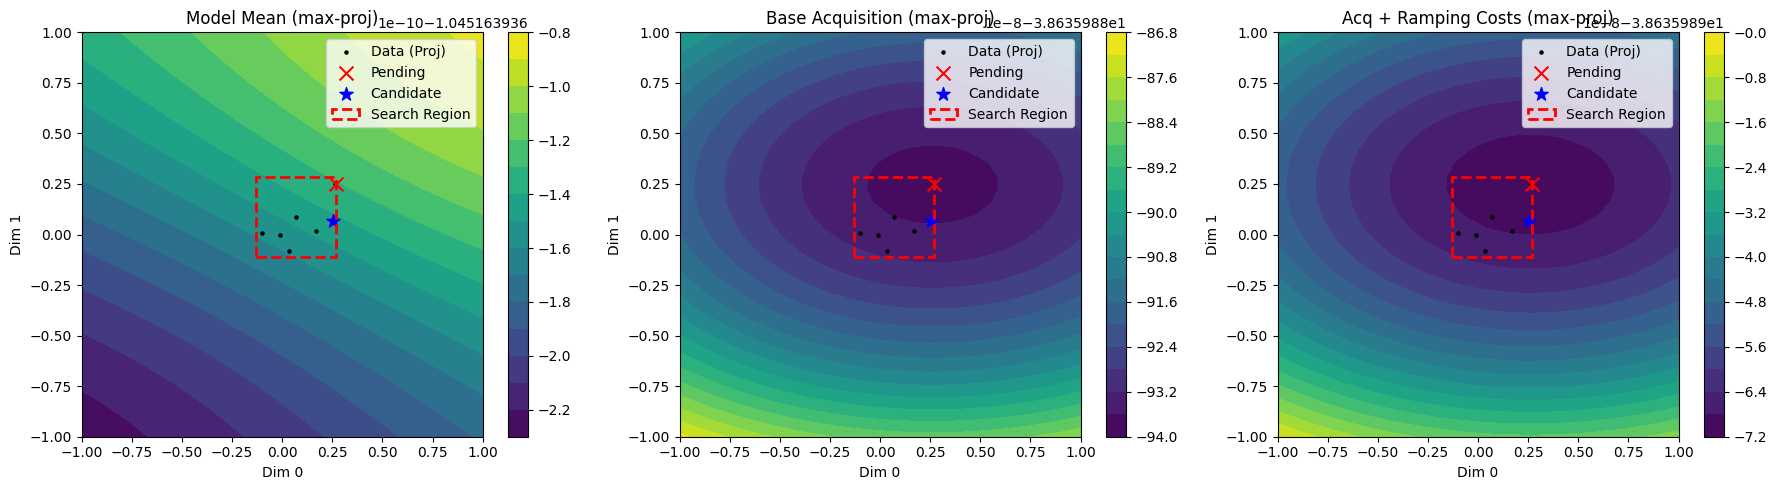

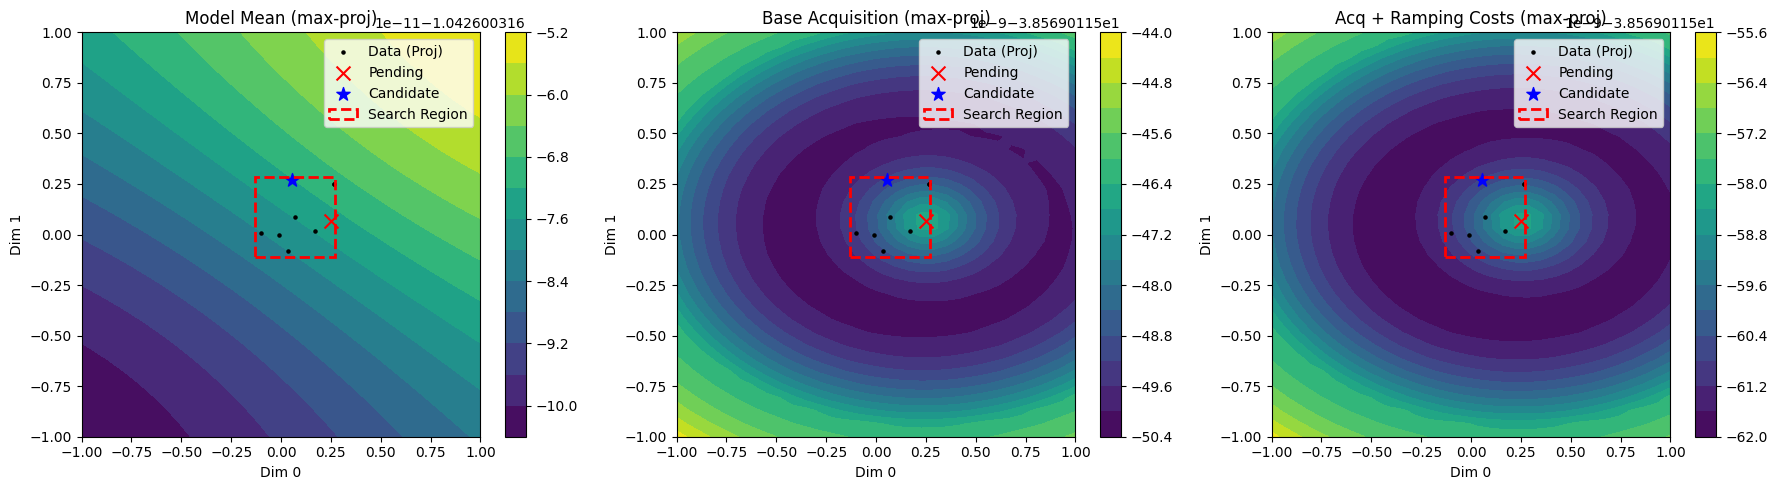

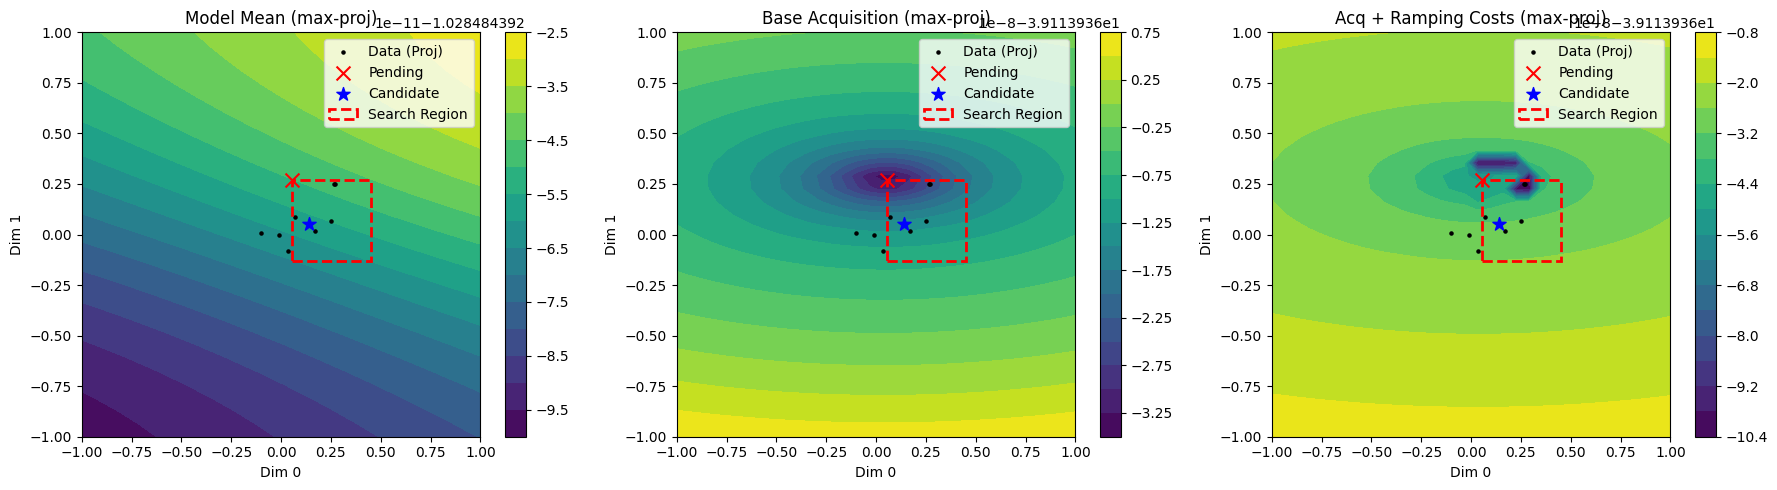

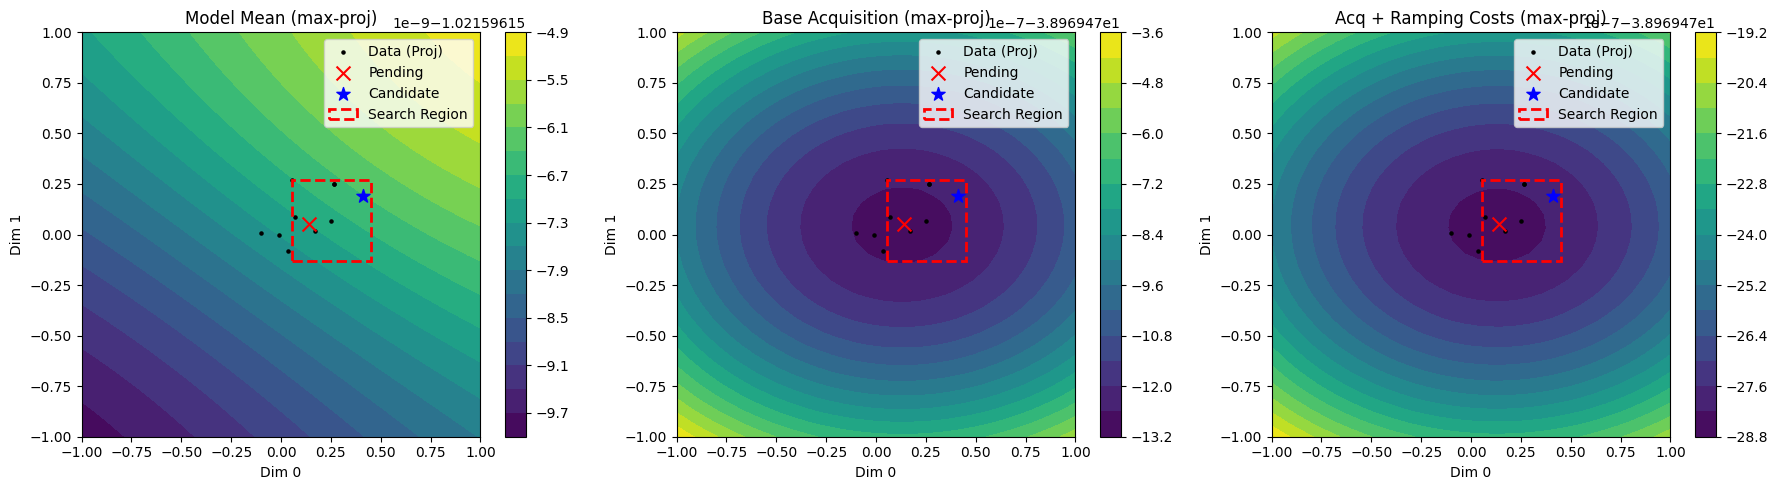

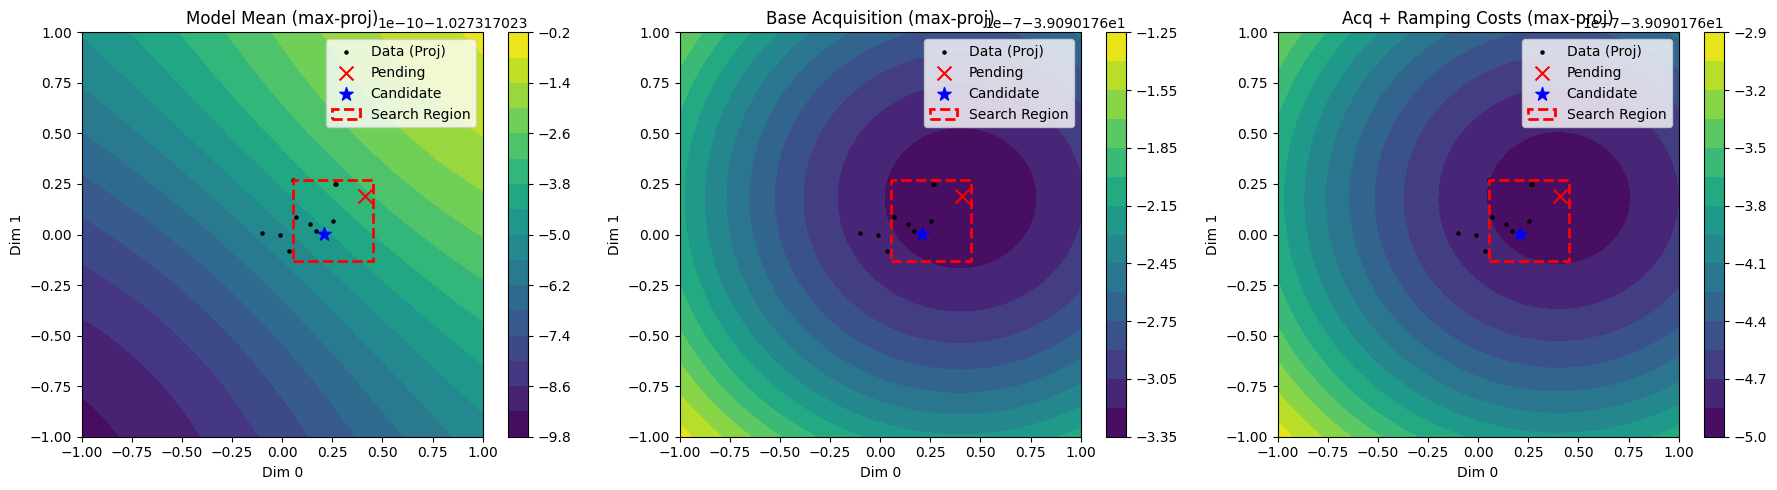

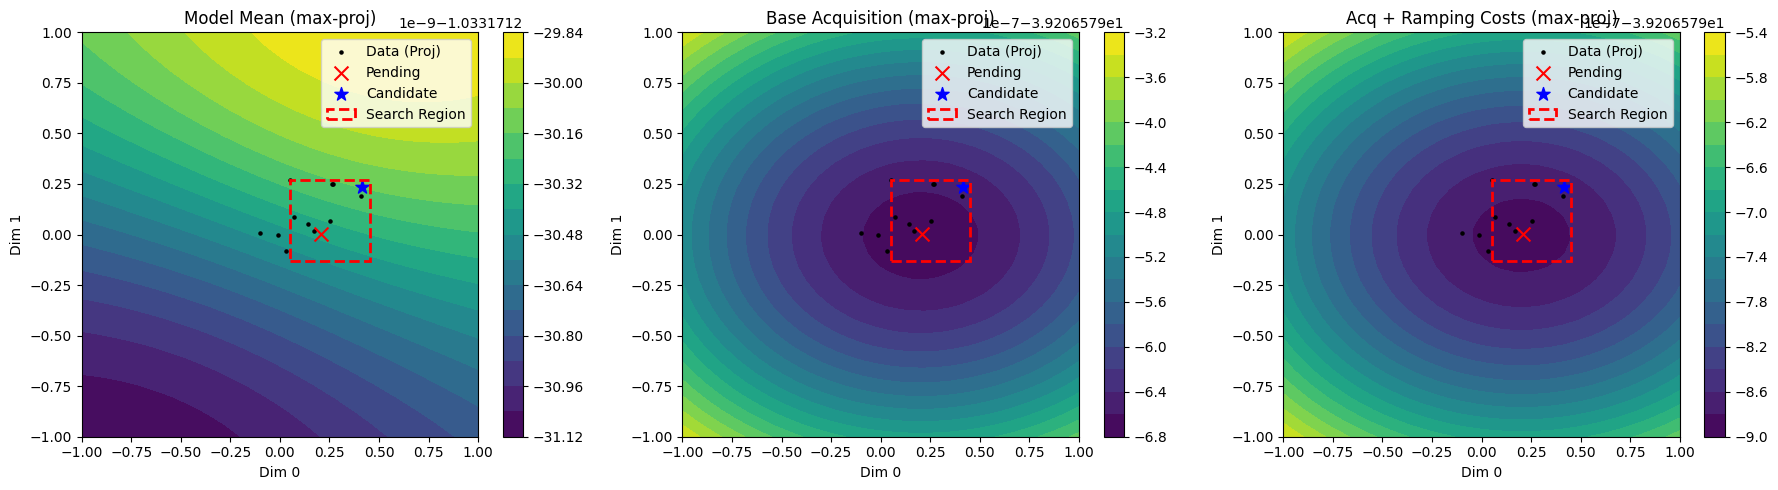

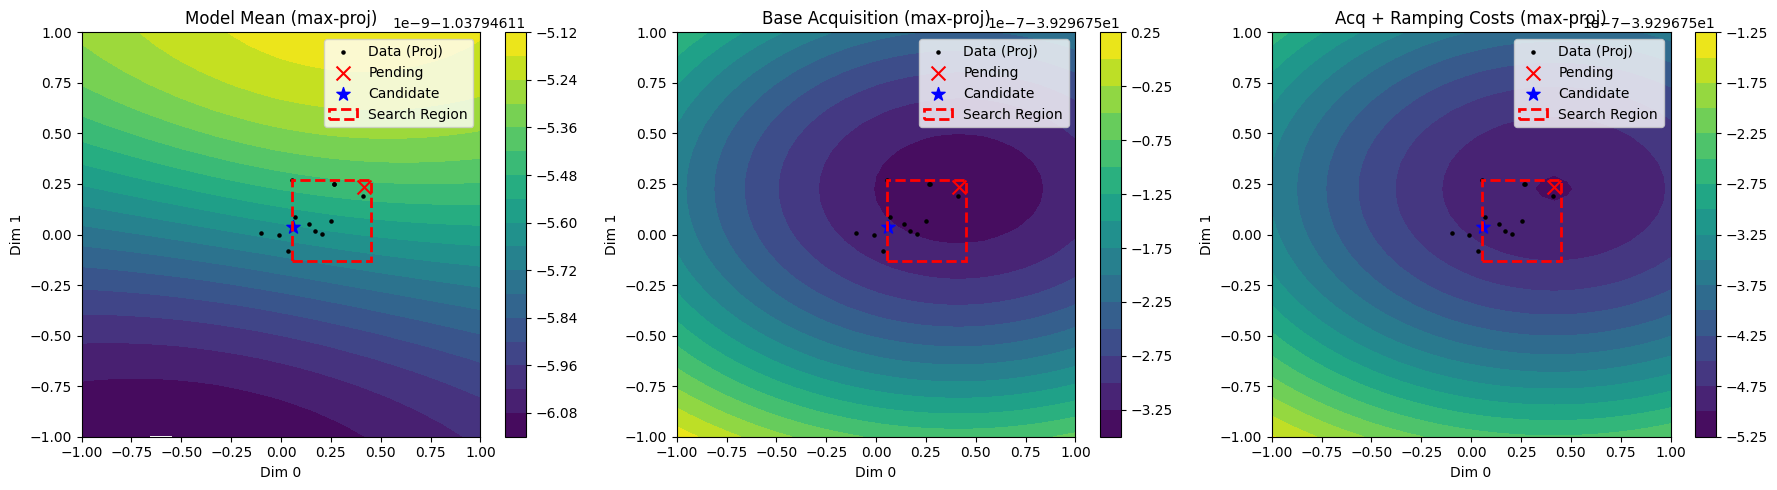

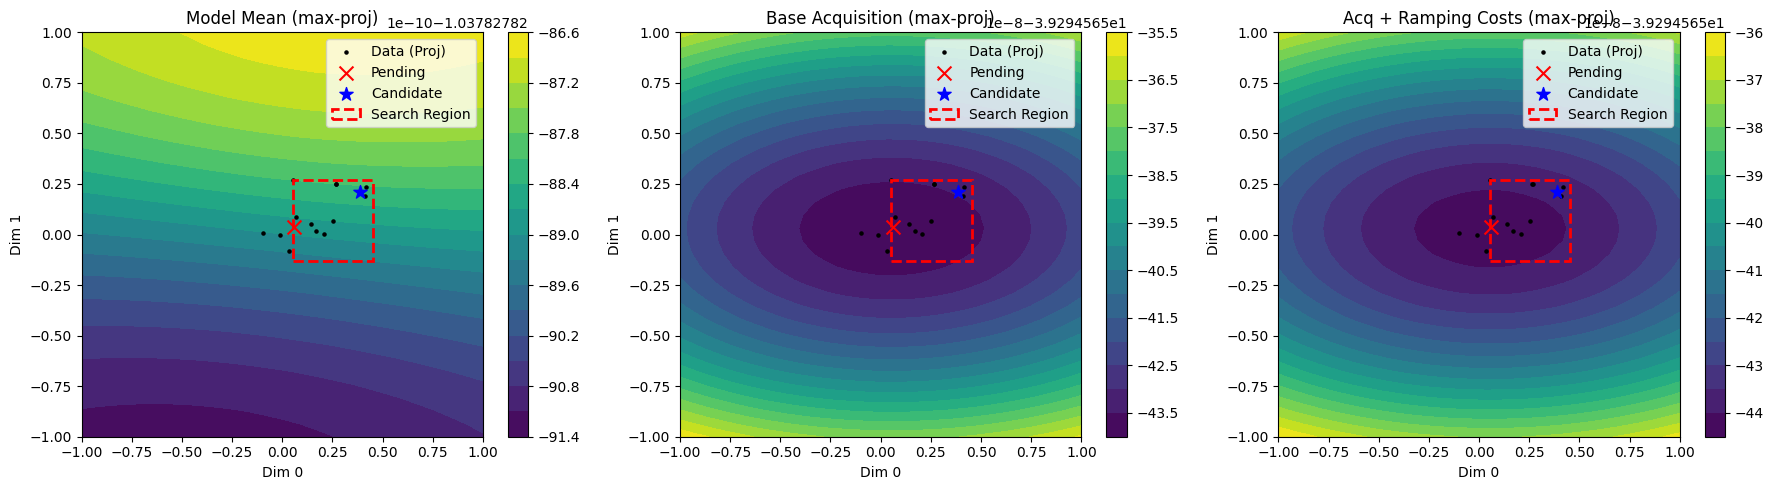

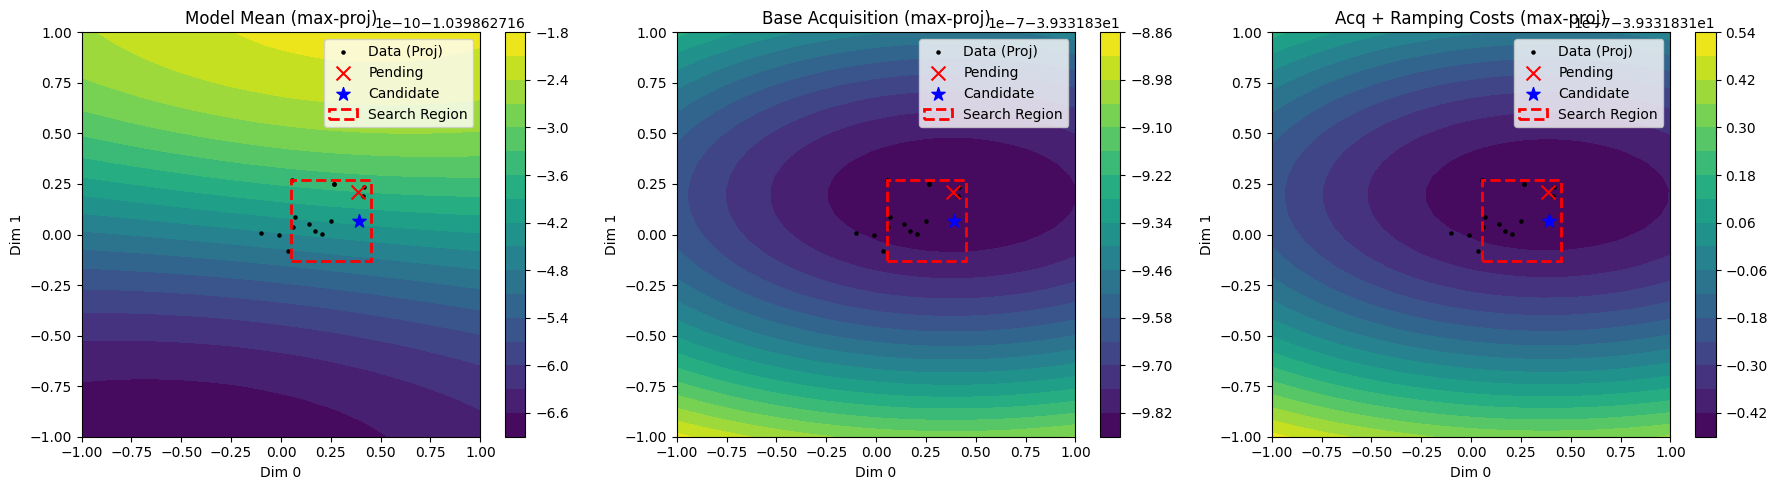

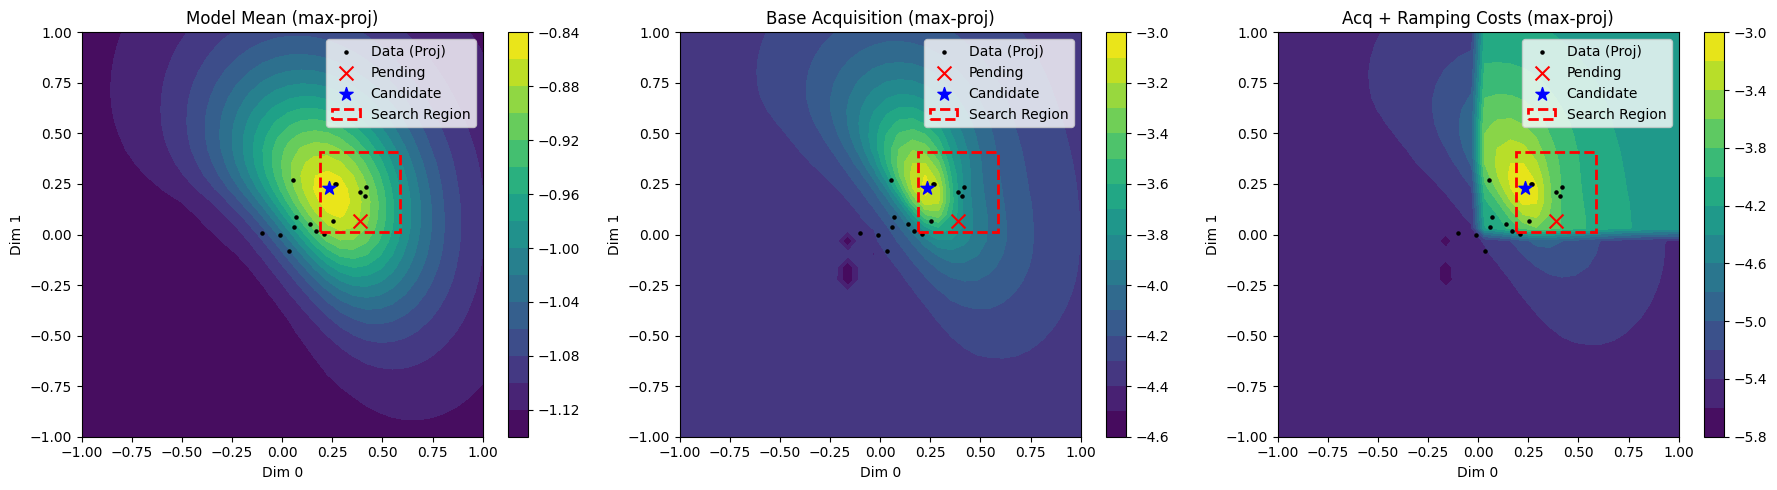

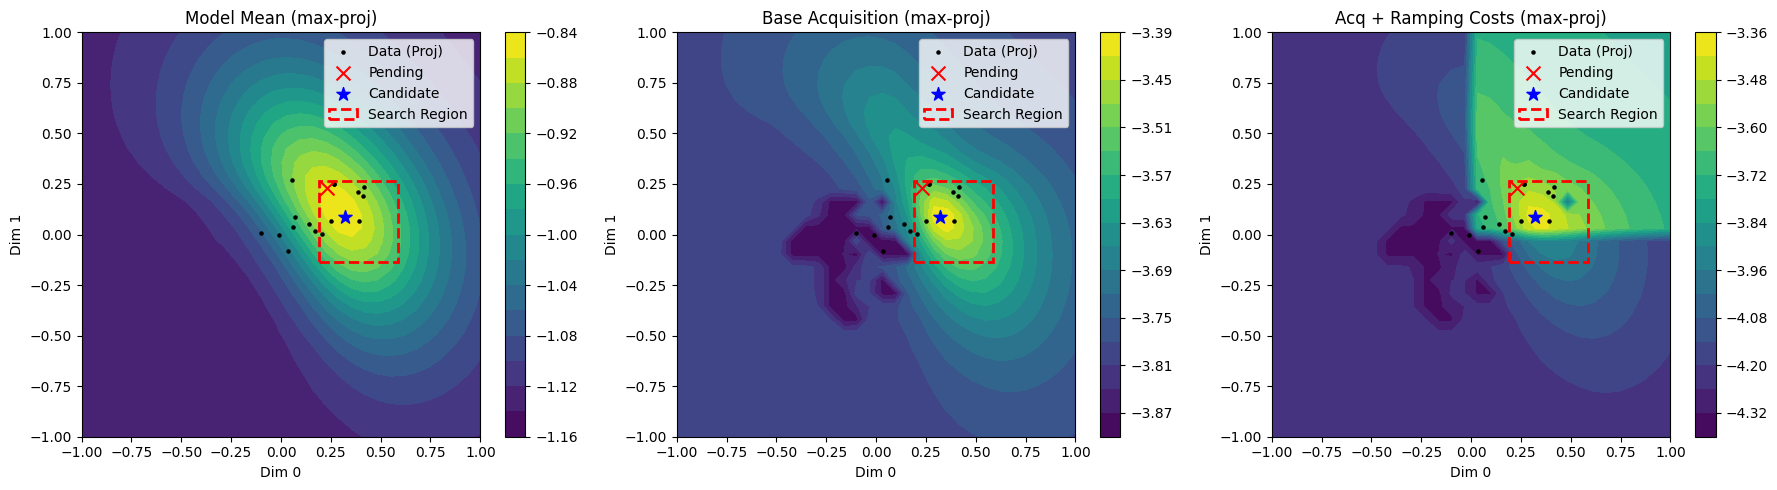

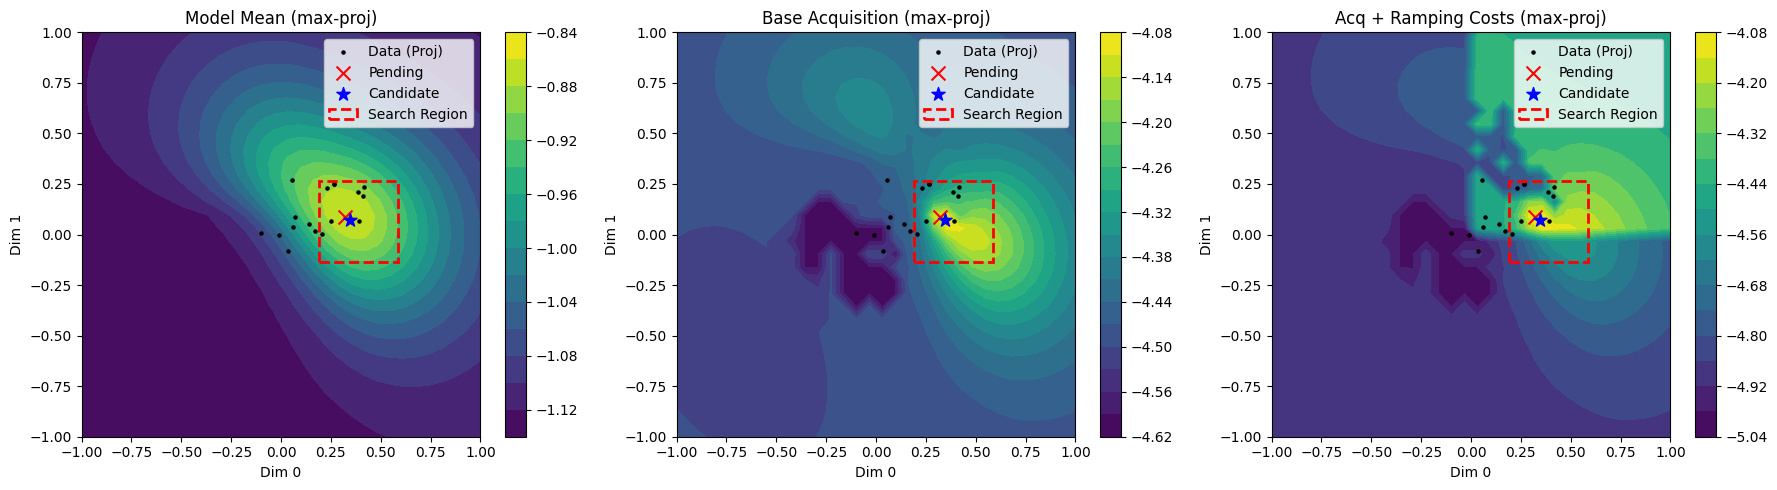

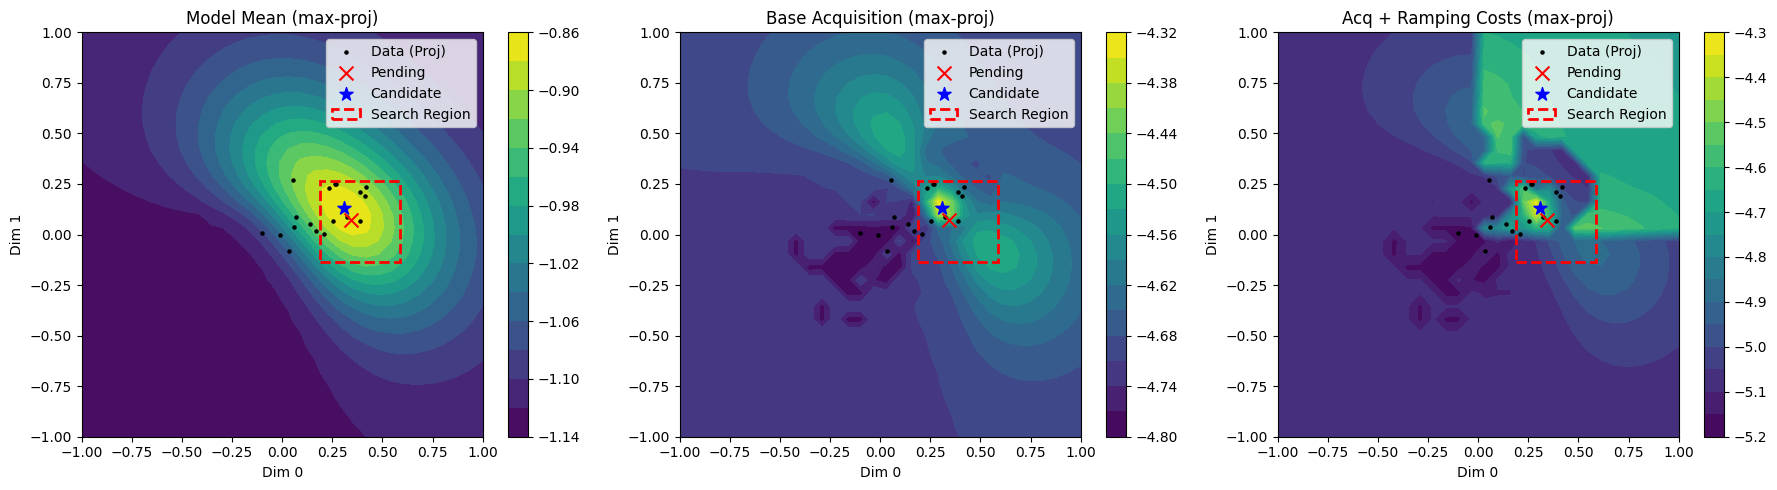

In [17]:
for _ in range(n_local):
    bo.step(mode="local", acq_type="qEI", fresh_train=True, plot_acq=True)
    plt.show()

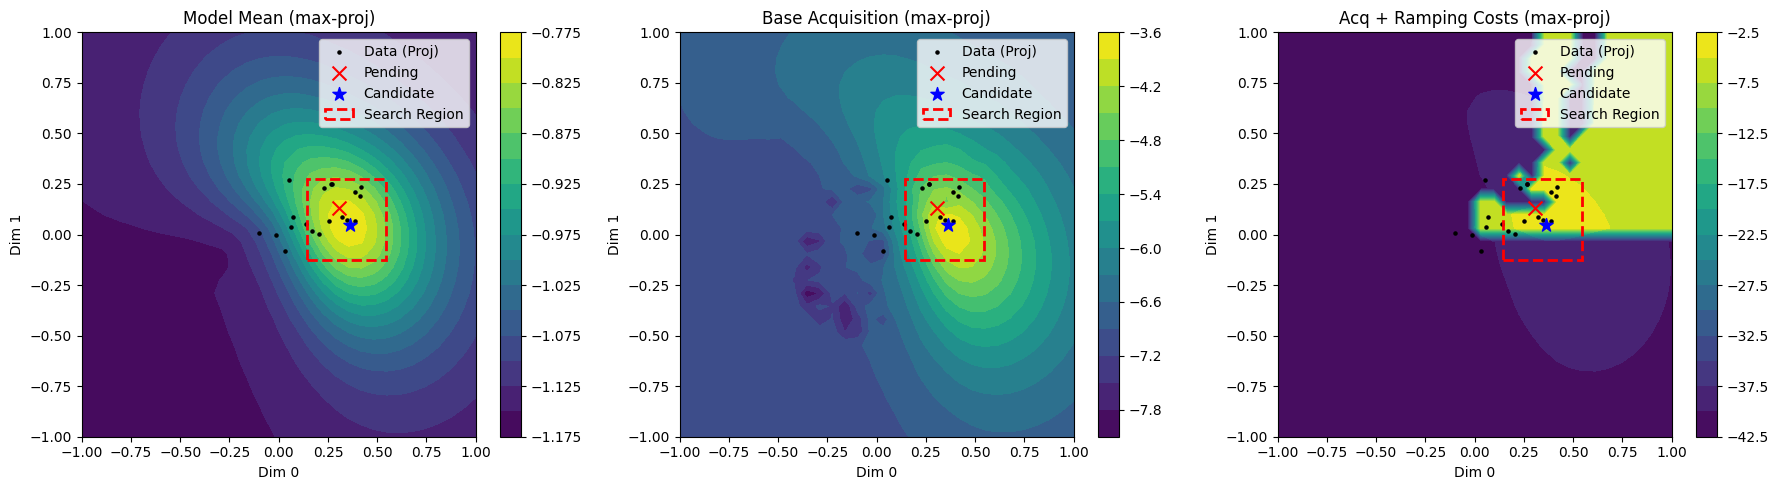

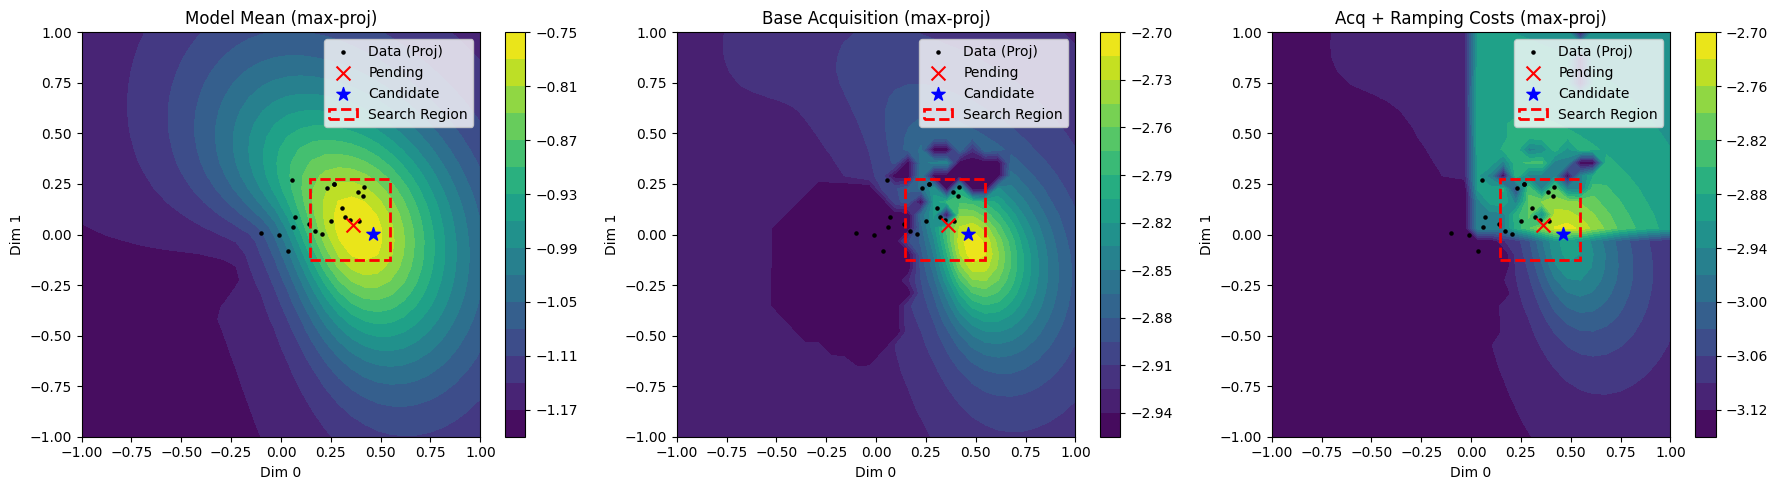

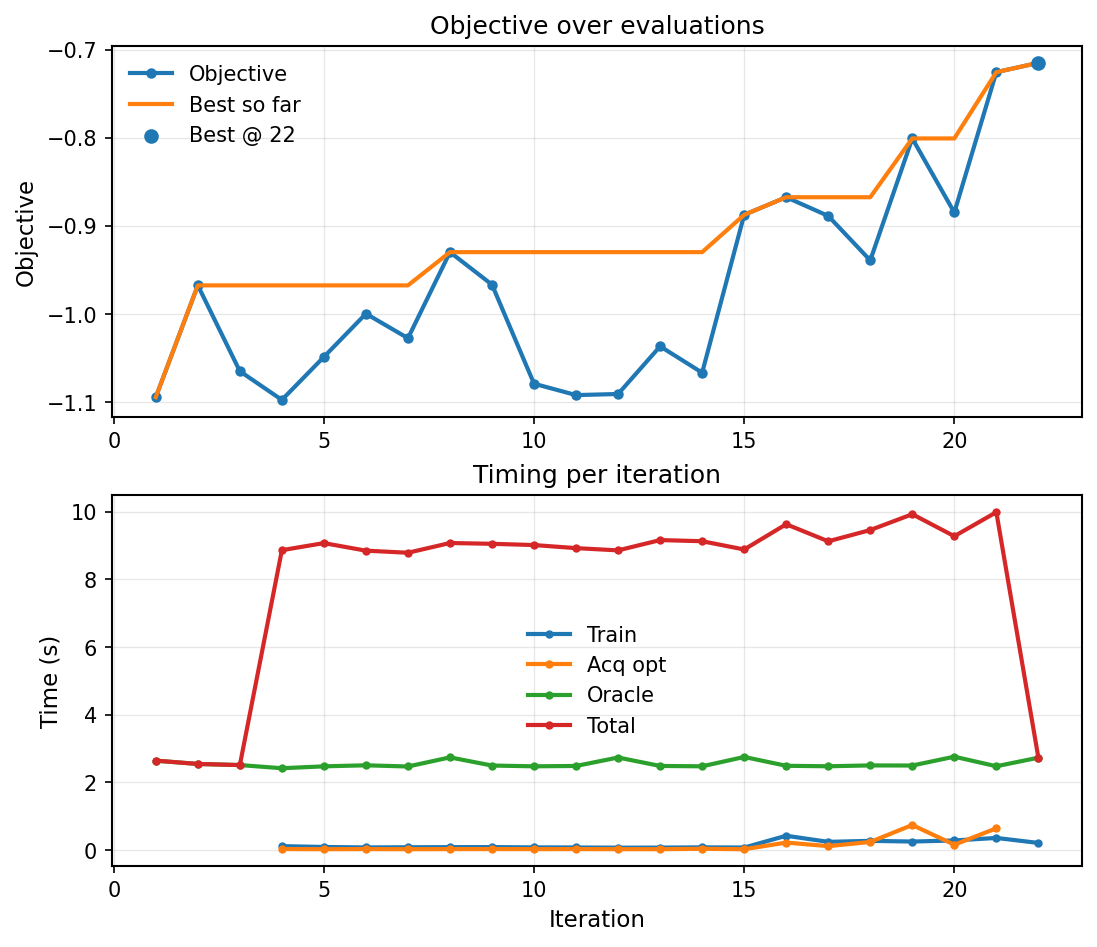

In [18]:
for _ in range(n_finetune):
    bo.step(mode="fine_tune", acq_type="qEI", fresh_train=True, plot_acq=True)
    plt.show()
bo.finalize()
bo.plot_history()
plt.show()

In [19]:
best = max(h["y"] for h in bo.history)
print("Best y:", best)

Best y: [-0.7150532]
